In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, make_moons, make_regression, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
np.random.seed(42)

In [2]:
tiny = pd.DataFrame({
    "monthly_usage": [2, 3, 4, 7, 8, 9],
    "support_calls": [8, 7, 6, 3, 2, 1],
    "churn": [1, 1, 1, 0, 0, 0]
})

query = np.array([5, 5])
tiny

,monthly_usage,support_calls,churn
0,2,8,1
1,3,7,1
2,4,6,1
3,7,3,0
4,8,2,0
5,9,1,0


In [5]:
def euclidean_distance(a, b):
    a = np.array(a)
    b = np.array(b)

    return np.sqrt(np.sum((a - b) ** 2))

X_tiny = tiny[["monthly_usage", "support_calls"]].values

distances = []

for idx, point in enumerate(X_tiny):
    distances.append({
        "point": f"P{idx}",
        "monthly_usage": point[0],
        "support_calls": point[1],
        "churn": tiny.loc[idx, "churn"],
        "distance_from_query": euclidean_distance(query, point)
    })

distance_table = pd.DataFrame(distances).sort_values("distance_from_query")
distance_table

,point,monthly_usage,support_calls,churn,distance_from_query
2,P2,4,6,1,1.414214
1,P1,3,7,1,2.828427
3,P3,7,3,0,2.828427
0,P0,2,8,1,4.242641
4,P4,8,2,0,4.242641
5,P5,9,1,0,5.656854


In [6]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

print(data.DESCR.split("\n")[0])
print("Shape:", X.shape)
print("Target names:", data.target_names)

pd.DataFrame({"target": y}).value_counts().rename("count")

.. _breast_cancer_dataset:
Shape: (569, 30)
Target names: ['malignant' 'benign']


,count
target,
1,357
0,212


In [7]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((455, 30), (455,), (114, 30), (114,))

In [11]:
knn_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_clf = knn_clf.fit(X_train, y_train)
y_pred = knn_clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [13]:
X_test.shape

(114, 30)

In [17]:
k_values = list(range(1, 36, 2))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_scores = []
cv_scores = []

for k in k_values:
    model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    cv_scores.append(cross_val_score(model, X_train, y_train, cv=cv, scoring="f1").mean())


score_df = pd.DataFrame({"K": k_values, "train_score": train_scores, "cv_score": cv_scores})
score_df.head()

,K,train_score,cv_score
0,1,1.000000,0.958104
1,3,0.978022,0.970673
2,5,0.973626,0.970489
3,7,0.975824,0.970665
4,9,0.973626,0.972351


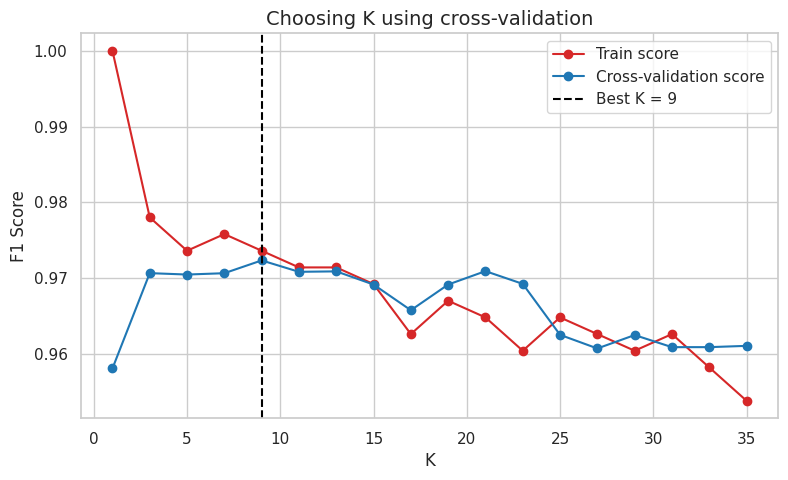

,4
K,9.000000
train_score,0.973626
cv_score,0.972351


In [18]:
best_row = score_df.loc[score_df["cv_score"].idxmax()]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(score_df["K"], score_df["train_score"], marker="o", label="Train score", color="#d62728")
ax.plot(score_df["K"], score_df["cv_score"], marker="o", label="Cross-validation score", color="#1f77b4")
ax.axvline(best_row["K"], color="black", linestyle="--", label=f"Best K = {int(best_row['K'])}")
ax.set_title("Choosing K using cross-validation")
ax.set_xlabel("K")
ax.set_ylabel("F1 Score")
ax.legend()
plt.show()

best_row

In [19]:
metric_results = []
for metric in ["euclidean", "manhattan"]:
    model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=9, metric=metric))
    ])

    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    metric_results.append({"metric": metric, "cv_accuracy_mean": scores.mean(), "cv_accuracy_std": scores.std()})
pd.DataFrame(metric_results)

,metric,cv_accuracy_mean,cv_accuracy_std
0,euclidean,0.972351,0.011390
1,manhattan,0.968902,0.017839


In [20]:
rng = np.random.RandomState(42)
X_reg = np.sort(8 * rng.rand(160, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + rng.normal(0, 0.25, X_reg.shape[0])


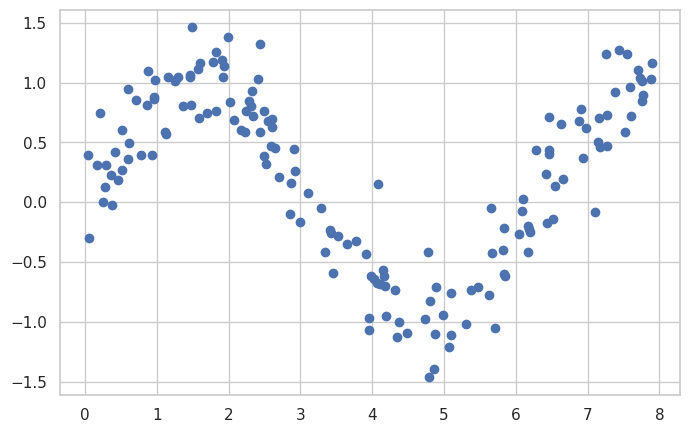

In [21]:
plt.plot(X_reg, y_reg, "o")

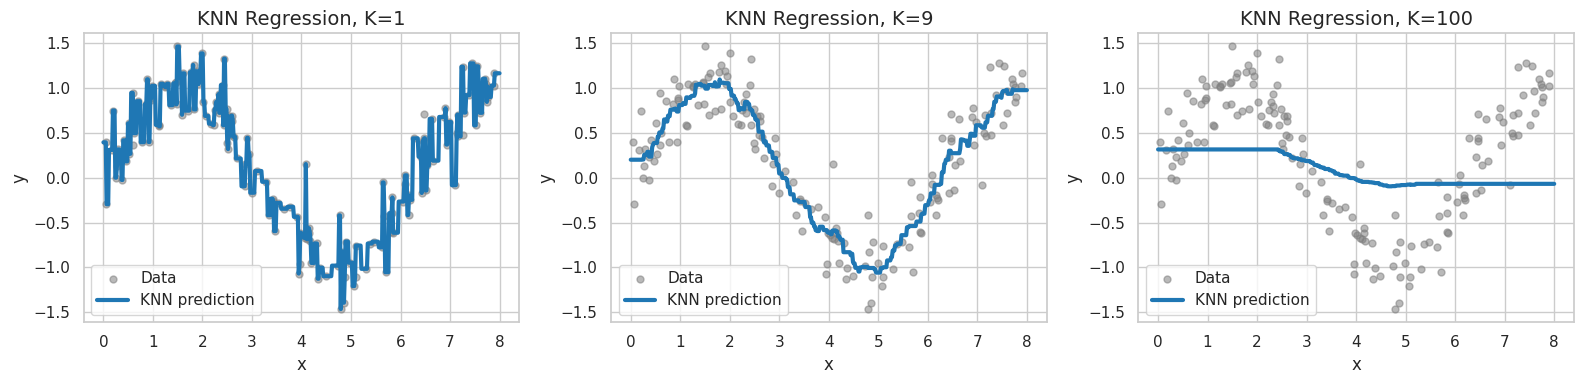

In [23]:
X_grid = np.linspace(0, 8, 500).reshape(-1, 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, k in zip(axes, [1, 9, 100]):
    reg = KNeighborsRegressor(n_neighbors=k)
    reg.fit(X_reg, y_reg)
    y_grid_pred = reg.predict(X_grid)

    ax.scatter(X_reg, y_reg, color="gray", alpha=0.55, s=25, label="Data")
    ax.plot(X_grid, y_grid_pred, color="#1f77b4", linewidth=3, label="KNN prediction")
    ax.set_title(f"KNN Regression, K={k}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
plt.tight_layout()
plt.show()

In [24]:
small_missing = pd.DataFrame({
    "age": [25, 27, 31, 45, 47, 50],
    "exercise_score": [8, 7, 7, 3, 2, 2],
    "bmi": [22, 23, np.nan, 31, 33, 34]
})
small_missing

,age,exercise_score,bmi
0,25,8,22.0
1,27,7,23.0
2,31,7,NaN
3,45,3,31.0
4,47,2,33.0
5,50,2,34.0


In [25]:
mean_imputer = SimpleImputer(strategy="mean")
knn_imputer = KNNImputer(n_neighbors=3)

mean_imputed = pd.DataFrame(mean_imputer.fit_transform(small_missing), columns=small_missing.columns)
knn_imputed = pd.DataFrame(knn_imputer.fit_transform(small_missing), columns=small_missing.columns)

print("Mean imputation")
display(mean_imputed)
print("KNN imputation")
display(knn_imputed)

Mean imputation


,age,exercise_score,bmi
0,25.0,8.0,22.0
1,27.0,7.0,23.0
2,31.0,7.0,28.6
3,45.0,3.0,31.0
4,47.0,2.0,33.0
5,50.0,2.0,34.0


KNN imputation


,age,exercise_score,bmi
0,25.0,8.0,22.000000
1,27.0,7.0,23.000000
2,31.0,7.0,25.333333
3,45.0,3.0,31.000000
4,47.0,2.0,33.000000
5,50.0,2.0,34.000000


In [26]:
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Best CV score: 0.9773897261895368
